<a href="https://colab.research.google.com/github/tlmakinen/degeneracy_distillery/blob/main/tutorial_notebooks/sir_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIR — Finding R₀ = β/γ

A clean, end-to-end run of the **Degeneracy Distillery** on the SIR
epidemiological model.

* **Parameters**: θ = (β, γ, I₀/10).
* **Data**: noisy I(t)/N at 30 time points.
* **Ground truth**: only R₀ = β/γ is identifiable from incidence
  alone; β and γ are individually degenerate.

Convention used in every tutorial notebook in this folder:

1. `MinMaxScaler((1, 2))` is applied to the *physical* θ **before** the
   Fishnet ensemble.
2. SR runs in the scaled coordinates and returns expressions in
   `X1, X2, ...` (with an optional `+1` shift fed to PyOperon).
3. After SR, `expressions_to_physical(…, scaler, sr_offset=1.0, …)`
   converts the discovered formulas back to physical-θ expressions in one
   line.


In [1]:
# Colab setup (skip if running locally with the package installed).
!git clone https://github.com/tlmakinen/degeneracy_distillery.git
%cd /content/degeneracy_distillery
!pip install -q -e .
%cd /content/
!git clone https://github.com/DeaglanBartlett/ESR.git
%cd /content/ESR
!pip install -q -e .


Cloning into 'degeneracy_distillery'...
remote: Enumerating objects: 936, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 936 (delta 88), reused 86 (delta 33), pack-reused 784 (from 1)
Receiving objects: 100% (936/936), 39.51 MiB | 18.71 MiB/s, done.
Resolving deltas: 100% (619/619), done.
/content/degeneracy_distillery
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.6/365.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 18.1 MB/s eta 0:00:

**Restart the runtime** before continuing on Colab.

In [ ]:
import os
os.kill(os.getpid(), 9)  # uncomment in Colab to restart


In [1]:
import esr.generation.generator  # ESR sanity check
import numpy as np
import jax, jax.numpy as jnp, jax.random as jr
import matplotlib.pyplot as plt
import sympy
from scipy.integrate import odeint
from tqdm import tqdm
import flax.linen as nn

from degeneracy_distillery.training_loop_fishnets import train_fishnets
from degeneracy_distillery.training_loop_flatten import fit_flattening
from degeneracy_distillery.align_coords import load_and_process_data_v2
from degeneracy_distillery.preprocessing_utils import weighted_std
from degeneracy_distillery.sr_utils import (
    fit_and_analyze_sr, analyze_equations, sr_structure_predicate,
    check_symbolic_invertibility,
    fit_theta_scaler, expressions_to_physical,
)
from degeneracy_distillery.postprocess_new import (
    analyze_atom_sharing, regroup_like_terms,
)
from degeneracy_distillery.postprocessing_utils import (
    print_discovered_expressions, get_y_sr,
    flatten_with_numerical_jacobian, check_flattening,
)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'figure.figsize': (8, 5), 'figure.dpi': 130,
    'savefig.dpi': 200, 'savefig.bbox': 'tight',
})


## 1. Simulator and data generation

In [2]:
key = jr.PRNGKey(42)
np.random.seed(42)

N_pop, I0_mean = 1000, 8
n_timepoints, t_max = 30, 50.0
t_obs = np.linspace(0, t_max, n_timepoints)
noise_std = 0.05

BETA_MIN, BETA_MAX = 0.1, 1.0
GAMMA_MIN, GAMMA_MAX = 0.05, 0.5
nsims = 500
delta = 0.15  # supercriticality cut: keep beta/gamma >= 1 + delta


def sir_odes(y, _t, beta, gamma, N):
    S, I, R = y
    return [-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I]


def simulate_sir(beta, gamma, noise_key):
    I0 = np.random.poisson(I0_mean)
    S0 = N_pop - I0
    sol = odeint(sir_odes, [S0, I0, 0.0], t_obs, args=(beta, gamma, N_pop))
    I_t = sol[:, 1] / N_pop
    I_t = I_t + np.array(jr.normal(noise_key, shape=I_t.shape)) * noise_std
    return I_t.astype(np.float32), I0 / 10.0


def generate(rng_key, n, label):
    key1, key2 = jr.split(rng_key)
    pool = max(4 * n, 4 * nsims)
    beta_pool = np.random.uniform(BETA_MIN, BETA_MAX, pool)
    gamma_pool = np.random.uniform(GAMMA_MIN, GAMMA_MAX, pool)
    keep = (beta_pool / gamma_pool) >= (1.0 + delta)
    beta_pool = beta_pool[keep][:n]
    gamma_pool = gamma_pool[keep][:n]
    keys = jr.split(key2, n)
    data, I0s = [], []
    for i in tqdm(range(n), desc=label):
        d, i0 = simulate_sir(beta_pool[i], gamma_pool[i], keys[i])
        data.append(d); I0s.append(i0)
    theta = np.stack([beta_pool, gamma_pool, np.array(I0s)], axis=1).astype(np.float32)
    return theta, np.array(data, dtype=np.float32)


key, sub = jr.split(key)
theta_train, data_train = generate(sub, nsims, "train")
key, sub = jr.split(key)
theta_test,  data_test  = generate(sub, nsims, "test")
print("theta_train", theta_train.shape, "data_train", data_train.shape)


test: 100%|██████████| 500/500 [00:00<00:00, 512.00it/s]

theta_train (500, 3) data_train (500, 30)


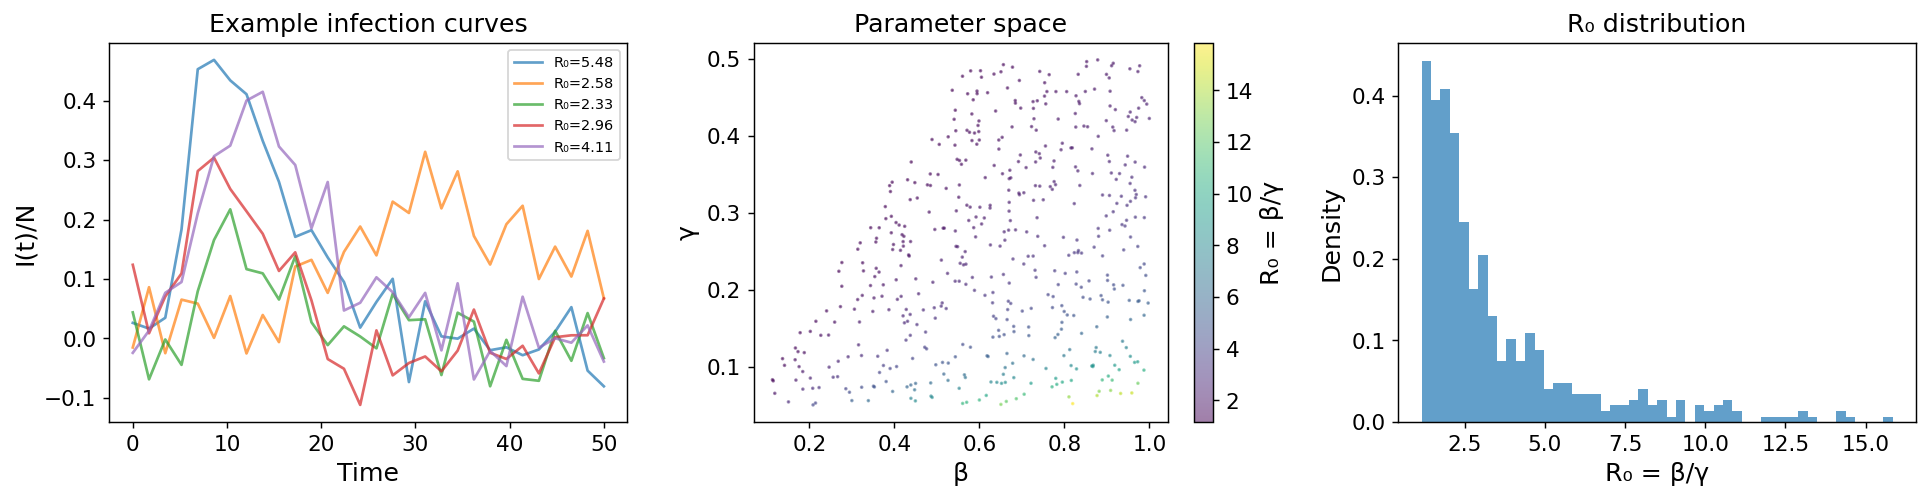

In [3]:
# Plot example SIR curves for different R_0 values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Example curves
for idx in np.random.choice(nsims, 5, replace=False):
    R0_val = theta_train[idx, 0] / theta_train[idx, 1]
    axes[0].plot(t_obs, data_train[idx], alpha=0.7, label=f'R₀={R0_val:.2f}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('I(t)/N')
axes[0].set_title('Example infection curves')
axes[0].legend(fontsize=8)

# Parameter space colored by R_0
R0_vals = np.array(theta_train[:, 0] / theta_train[:, 1])
sc = axes[1].scatter(theta_train[:, 0], theta_train[:, 1], c=R0_vals,
                     s=1, alpha=0.5, cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='R₀ = β/γ')
axes[1].set_xlabel('β')
axes[1].set_ylabel('γ')
axes[1].set_title('Parameter space')

# R_0 distribution
axes[2].hist(R0_vals, bins=50, density=True, alpha=0.7)
axes[2].set_xlabel('R₀ = β/γ')
axes[2].set_ylabel('Density')
axes[2].set_title('R₀ distribution')

plt.tight_layout()
plt.savefig('sir_data_overview.pdf')
plt.show()

## 2. Pre-fishnet rescaling

`fit_theta_scaler` is the single source of truth for the scaling map; we keep
it around and reuse it for the SR sample pool and for the final
physical-θ substitution.

In [4]:
scaler = fit_theta_scaler(theta_train, feature_range=(1.0, 2.0))
theta_train_s = scaler.transform(theta_train).astype(np.float32)
theta_test_s  = scaler.transform(theta_test).astype(np.float32)
print("data_min:", scaler.data_min_)
print("data_max:", scaler.data_max_)
print("scaled range:", theta_train_s.min(0), theta_train_s.max(0))


data_min: [0.1130902  0.05006061 0.1       ]
data_max: [0.9997459  0.49901938 1.5       ]
scaled range: [1. 1. 1.] [2. 2. 2.]


## 3. Fisher-network ensemble

We feed the network only `(β_s, γ_s)`; `I0/10` is a per-realization
nuisance, so it is excluded from the Fishnet target.

In [ ]:
embedding_net = nn.Sequential([
    nn.Dense(64), nn.gelu,
    nn.Dense(32), nn.gelu,
])

_ = train_fishnets(
    theta_train_s[:, :2], data_train,
    theta_test_s[:, :2],  data_test,
    num_models=10,
    train_epochs=5000, patience=30,
    n_layers=[2, 5], hids_min=50, hids_max=300,
    embedding_net=embedding_net,
    lr=5e-5, train_batch_size=200,
    outdir="fishnets-sir",
)


saving to fishnets-sir
data_test shape: (500, 30)
theta_test shape: (500, 2)
Chosen hidden size for model 1 : 89 | layers: 5
Chosen hidden size for model 2 : 120 | layers: 2
Chosen hidden size for model 3 : 276 | layers: 5
Chosen hidden size for model 4 : 139 | layers: 5
Chosen hidden size for model 5 : 225 | layers: 2
Chosen hidden size for model 6 : 263 | layers: 5
Chosen hidden size for model 7 : 164 | layers: 4
Chosen hidden size for model 8 : 95 | layers: 4
Chosen hidden size for model 9 : 119 | layers: 5
Chosen hidden size for model 10 : 191 | layers: 2
STARTING TRAINING LOOP

Training model 1 of 10


Epoch 2436 loss: -9.82981 ; val_loss: -4.64128:  49%|████▊     | 2436/5000 [01:08<01:12, 35.56it/s]



Early stopping triggered at epoch 2436

Training model 2 of 10


Epoch 2898 loss: -9.77539 ; val_loss: -4.58418:  58%|█████▊    | 2898/5000 [01:01<00:44, 47.41it/s]



Early stopping triggered at epoch 2898

Training model 3 of 10


...


Early stopping triggered at epoch 2318

Training model 9 of 10


Epoch 2257 loss: -9.91036 ; val_loss: -4.66227:  45%|████▌     | 2257/5000 [00:58<01:10, 38.78it/s]



Early stopping triggered at epoch 2257

Training model 10 of 10


Epoch 2213 loss: -9.98882 ; val_loss: -4.56588:  44%|████▍     | 2213/5000 [00:48<01:01, 45.19it/s]



Early stopping triggered at epoch 2213
Ensemble weights: [108.20047   98.86287  115.660095 108.52056   98.13573   44.17038
 114.71428  102.18037  107.84423   98.32313 ]
Training completed. Outputs saved to: fishnets-sir/fishnets_outputs.npz
Note: Load with io_utils.load_fishnets_results(file) for alias support


## 4. Flattening Network


In [ ]:
fish = np.load("fishnets-sir/fishnets_outputs.npz")
thetas = jnp.array(fish["theta"])
ensemble_weights = fish["ensemble_weights"]
F_network_ensemble = jnp.array(fish["Fs"])

w, ensemble_ws, output_dict, flatten_model = fit_flattening(
    F_network_ensemble=F_network_ensemble,
    θs=thetas,
    ensemble_weights=ensemble_weights,
    flattener_activation="softplus",
    loss_type="log_frob",
    forward_backward_mlp=True,
    forward_backward_invertibility_weight=1.0,
    n_layers=8,
    offset=0.0, beta_det=0.1, noise=1e-2,
    batch_size=50,
    finetune_epochs=200, epochs_phase1=1000, epochs_phase2=500,
    lr_phase1=2e-6, lr_schedule_initial=7e-5, lr_decay=0.3,
    l1_alpha=0.0, do_plot=False,
    Fisher_to_flatten="average",
    output_prefix="sir_flatten",
    return_model=True,
)


AVERAGING FISHERS (weighted ensemble)
COMPUTING ROBUST NORM FACTOR (method: median_max_eig)
norm_factor = 722.607
COMPUTING WHITENING TRANSFORM
Global mean Fisher shape: (2, 2)
Global mean Fisher:
[[ 0.57219756 -0.42900753]
 [-0.42900753  2.2190435 ]]
Mean Fisher eigenvalues: [0.46714172 2.3240993 ]
W_inv transformation:  [[ 0.7310577  -0.19429886]
 [-0.1942989   1.4769195 ]]
Whitened Fisher global mean (should be ~I):
[[ 1.0000000e+00 -1.4901161e-08]
 [-2.9802322e-08  1.0000001e+00]]
W_inv condition number: 2.23
Flattener activation: softplus
Loss type: log_frob
Min-max input scaling: True
Min-max post-scale offset: 0.0
USING WHITENED forward–backward MLP (forward WhitenedMLP + ReversePathMLP)
TRAINING FLATTENER NET


epoch 999 loss: 0.6755, det F(η): 1.2703, val det F(η): 1.3328: 100%|██████████| 1000/1000 [01:24<00:00, 11.80it/s]


FINE-TUNING FLATTENER NET


epoch 499 loss: 0.6436, det F(η): 1.1083, val det F(η): 1.1579: 100%|██████████| 500/500 [00:46<00:00, 10.84it/s]


FINE-TUNING EACH ENSEMBLE MEMBER
fine-tuning for ensemble member 0


...

fine-tuning for ensemble member 8


epoch 199 loss: 0.6531, det F(η): 0.9692, val det F(η): 0.9933: 100%|██████████| 200/200 [00:26<00:00,  7.65it/s]


fine-tuning for ensemble member 9


epoch 199 loss: 0.6668, det F(η): 1.0048, val det F(η): 1.0613: 100%|██████████| 200/200 [00:25<00:00,  7.96it/s]


applying model to ensemble member 0
applying model to ensemble member 1
applying model to ensemble member 2
applying model to ensemble member 3
applying model to ensemble member 4
applying model to ensemble member 5
applying model to ensemble member 6
applying model to ensemble member 7
applying model to ensemble member 8
applying model to ensemble member 9
CALCULATING JACOBIAN ERROR
ROTATING ENSEMBLE COORDINATES
Note: Load with io_utils.load_flattening_results(file) for alias support
EXPERIMENT COMPLETED & RESULTS SAVED TO: sir_flatten.npz
Saved flattener module + weights to: sir_flatten_flatten_model.pkl


## 5. SR-only sample pool

Cheap pool of θ samples (no simulator, just θ) we feed through the
trained flattener for the SR step.  We pass them through the *same* scaler
that the fishnets saw.

In [ ]:
rng_sr = np.random.default_rng(456)
n_sr = 10_000

beta_sr  = rng_sr.uniform(BETA_MIN, BETA_MAX, n_sr)
gamma_sr = rng_sr.uniform(GAMMA_MIN, GAMMA_MAX, n_sr)
I0_sr    = rng_sr.poisson(I0_mean, n_sr) / 10.0
theta_sr_phys = np.stack([beta_sr, gamma_sr, I0_sr], axis=1).astype(np.float32)

# supercriticality cut, mirroring the training set
keep = (beta_sr / gamma_sr) >= (1.0 + delta)
theta_sr_phys = theta_sr_phys[keep]

# scale and select the (beta_s, gamma_s) channels the fishnet was trained on
X_sr = scaler.transform(theta_sr_phys)[:, :2].astype(np.float32)

ys_sr = jnp.array([
    jax.vmap(lambda x: flatten_model.apply(w_i, x))(X_sr)
    for w_i in ensemble_ws
])
print("X_sr", X_sr.shape, "ys_sr", ys_sr.shape)


X_sr (7602, 2) ys_sr (10, 7602, 2)


## 6. Coordinate alignment

`align_coords.load_and_process_data_v2` runs Procrustes+sign canonicalization
on the ensemble Jacobians and returns the aligned `(X, y, dy_sr, Fs)` we feed
to symbolic regression.

In [ ]:
data = load_and_process_data_v2(
    datapath="./",
    filename="sir_flatten.npz",
    num_samps=4000, seed=44,
    process_ensemble=True, n_d=1.0,
    align_mode="procrustes",
    separate_nonlinearity=False,
    canonicalize="sign_only",
    use_prior_normalization=True,
    restore_reference_mean=False,
    Fisher_to_flatten="average",
    verbose=False,
)

X = data["X"]
m  = X[:, 0] > 0.0   # standard mask for the small SIR run
X, y, y_std, dy_sr, Fs = X[m], data["y"][m], data["y_std"][m], data["dy_sr"][m], data["Fs"][m]
ys = np.array([yy[m] for yy in data["ys"]])
n_params = X.shape[1]

# floor y so y >= 1 (PyOperon-friendly)
ymin_ = y.min(0) - 1.0
y -= ymin_
ys -= ymin_

# rotate the SR pool into the same aligned frame
ys_sr_rot = np.array([
    np.einsum("ij,bj->bi", data["rotmats"][i], ys_sr[i] - ys_sr[i].mean(0))
    for i in range(len(ys_sr))
])
y_std_sr = weighted_std(ys_sr_rot, data["ensemble_weights"])
y_sr = np.average(ys_sr_rot, 0, data["ensemble_weights"])
ys_sr_rot -= y_sr.min(0); y_sr -= y_sr.min(0)
y_sr += 1; ys_sr_rot += 1
print("aligned X", X.shape, "y", y.shape)


aligned X (500, 2) y (500, 2)


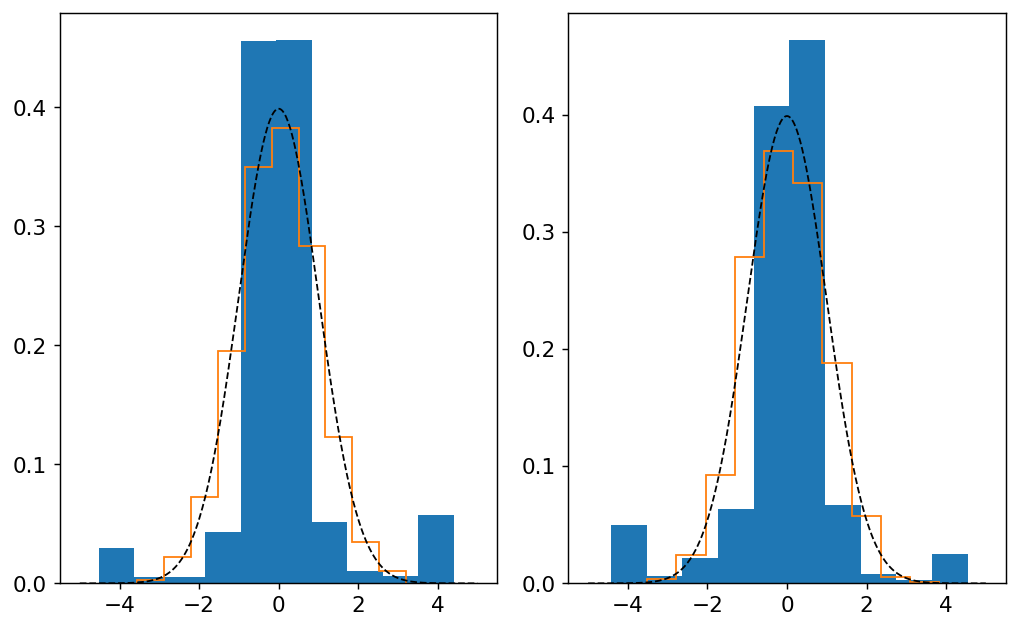

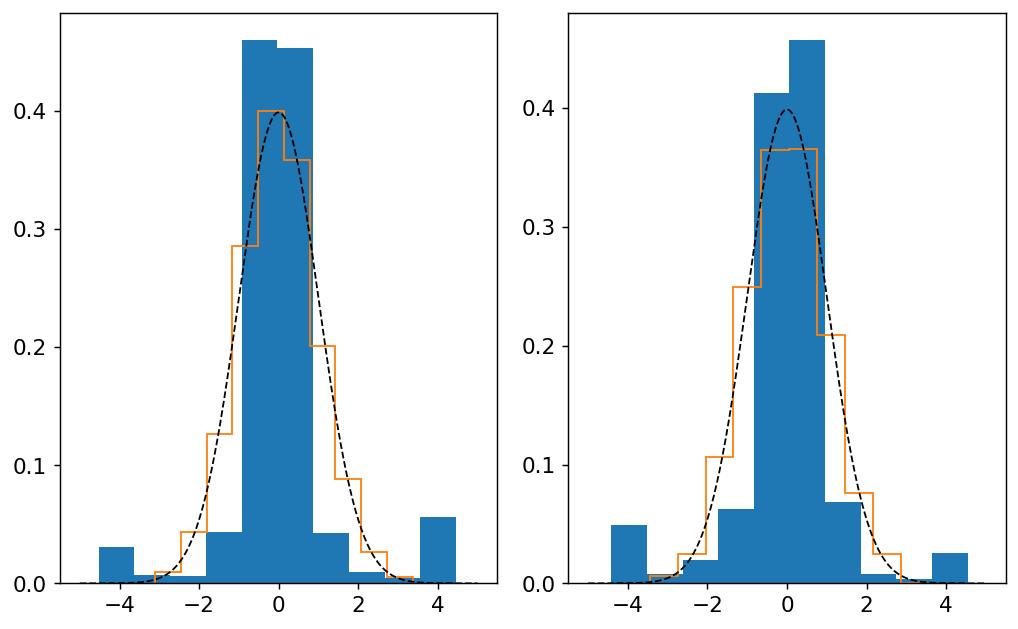

In [ ]:
# check coordinate sampling distribution

fig,axs = plt.subplots(1,n_params)
axs = axs.flatten()

bins = [-5, 5]

for i,ax in enumerate(axs):
    ax.hist(((ys[:, :, ...] - y) / y_std)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)
    ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")

    # ax.set_xlim(-10, 10)
plt.tight_layout()
plt.show()


fig,axs = plt.subplots(1,n_params)
axs = axs.flatten()

bins = [-5, 5]

for i,ax in enumerate(axs):
    ax.hist(((ys_sr_rot - y_sr) / y_std_sr)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)
    ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")

    # ax.set_xlim(-10, 10)
plt.tight_layout()
plt.show()

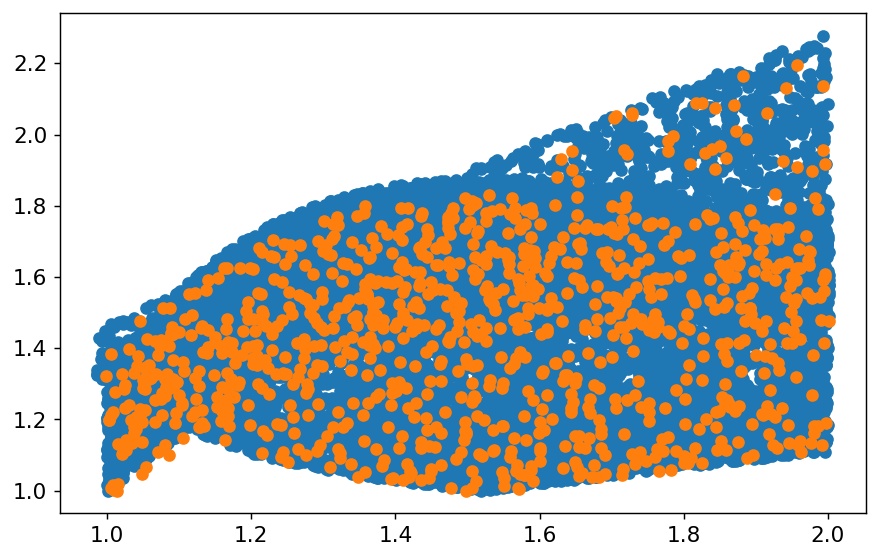

In [ ]:
plt.scatter(X_sr, y_sr)
plt.scatter(X, y)

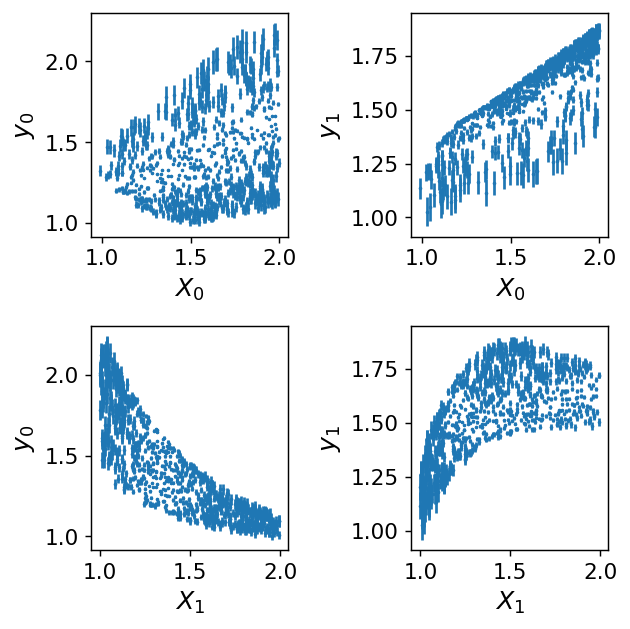

In [ ]:
# create scatterplot to see how y responds to X

fig, axs = plt.subplots(n_params, n_params, figsize=(5,5))

skip=10

for i in range(X_sr.shape[-1]):
    for j in range(y_sr.shape[-1]):

        # row, column
        axs[i,j].errorbar(X_sr[::skip,i], y_sr[::skip, j], yerr=y_std_sr[::skip, j], label='', fmt='o', markersize=1)

        axs[i,j].set_xlabel(r"$X_%d$"%(i))
        axs[i,j].set_ylabel(r"$y_%d$"%(j))

plt.tight_layout()
plt.show()

## 7. Symbolic regression

In [ ]:
SR_OFFSET = 0.0   # what we add to X before feeding PyOperon

from degeneracy_distillery.sr_utils import fit_symbolic_regression

fit_symbolic_regression(
    X_sr, y_sr, y_std_sr,
    parent_dir='./sr_results_sir/',
    random_state=32134,
    time_limit=60*5,
    max_length=25,
    max_depth=10,
    allowed_symbols='add,mul,div,pow,constant,variable,sqrt',
    )


Fitting component 1 of 2 (index 0)
X train shape: (7602, 2), y train shape: (7602,)
Fitting...
Done!
Best model: ((-0.04) + (1.03 * (sqrt((0.94 * X1)) / (0.63 * X2))))
Stats: {'model_length': 8, 'model_complexity': 12, 'generations': 48, 'evaluation_count': 0, 'residual_evaluations': 401614, 'jacobian_evaluations': 243193, 'random_state': 32134}
Outputting 16 individuals on Pareto front
Outputting 2000 individuals in population

Fitting component 2 of 2 (index 1)
X train shape: (7602, 2), y train shape: (7602,)
Fitting...
Done!
Best model: (0.00 + (1.00 * (((-7.15) + (11.03 * X2)) / ((0.03 * X1) ^ ((-0.36) * X2)))))
Stats: {'model_length': 11, 'model_complexity': 17, 'generations': 50, 'evaluation_count': 0, 'residual_evaluations': 435999, 'jacobian_evaluations': 258662, 'random_state': 32134}
Outputting 16 individuals on Pareto front
Outputting 2000 individuals in population


In [ ]:
mdl_coords, frob_coords, analysis = analyze_equations(
    X + SR_OFFSET, y, y_std, dy_sr, Fs,
    parent_dir="sr_results_sir/",
    n_params=n_params,
    equation_set="pareto",
    max_complexity_thresh=20,
    length_penalty=2.0,
    equation_predicate=sr_structure_predicate(
        n_params=n_params,
        forbid_self_transcendental=True,
        check_nested_exp=False,
    ),
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in mdl_coords])



Analysing component 1 of 2 (index 0)
Loading equations from: pareto.csv
11 equations below complexity threshold 20
5 / 11 equations pass equation_predicate (skipped 6)

Best MDL equation (complexity=9):
  (0.538402 + (59.416245 * ((0.010834 * X1) / ((-0.717975) + (1.414214 * X2)))))
  LaTeX: $\frac{X_{1} b_{1} b_{2}}{X_{2} b_{4} + b_{3}} + b_{0}$

Best Frob loss equation (complexity=9):
  (0.538402 + (59.416245 * ((0.010834 * X1) / ((-0.717975) + (1.414214 * X2)))))
  LaTeX: $\frac{X_{1} b_{1} b_{2}}{X_{2} b_{4} + b_{3}} + b_{0}$

Analysing component 2 of 2 (index 1)
Loading equations from: pareto.csv
11 equations below complexity threshold 20
2 / 11 equations pass equation_predicate (skipped 9)

Best MDL equation (complexity=5):
  (0.669648 + (0.575652 * (0.964952 * X1)))
  LaTeX: $X_{1} b_{1} b_{2} + b_{0}$

Best Frob loss equation (complexity=5):
  (0.669648 + (0.575652 * (0.964952 * X1)))
  LaTeX: $X_{1} b_{1} b_{2} + b_{0}$

DISCOVERED EXPRESSIONS
  η_1 = (0.64*X1 + 0.76*X2 - 0.3

## 8. Postprocessing (`postprocess_new`)

In [ ]:
report = analyze_atom_sharing(mdl_coords)
pruned_exprs, R, info = regroup_like_terms(
    mdl_coords, X=X, Fs=Fs, n_params=n_params,
    method="atoms",
    do_snap=True, snap_rel_tol=0.1, snap_flat_tol=0.1,
    decimal=2, threshold=1.0,
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in pruned_exprs])

inv = check_symbolic_invertibility(pruned_exprs, verbose=True)
print("inverse coords:", inv["inv_coords"])


extract_atoms: 2 rows, 3 unique atoms, ||C||_1 = 2.4072
reference flatness score: 1.577982
  outer  1/5: ||R C||_1 = 2.5470 (best 2.5470)
  outer  2/5: ||R C||_1 = 2.5476 (best 2.5470)
  outer  3/5: ||R C||_1 = 2.4873 (best 2.4873)
  outer  4/5: ||R C||_1 = 2.4653 (best 2.4653)
  outer  5/5: ||R C||_1 = 2.4547 (best 2.4547)
  done. L1 2.4072 -> 2.4547; exact-zero fraction 33.33% -> 0.00%; ortho err 2.67e-07
post-rotation flatness: 1.414213 (rel Δ = 10.38%, tol = 10.00%)
rotation rejected (flatness degraded too much); falling back to input expressions.
snapping shared coefficients...
final flatness: 1.577982
snapping inner-factor coefficients...
final flatness after inner snap: 1.577982

DISCOVERED EXPRESSIONS
  η_1 = (0.64*X1 + 0.76*X2 - 0.39)/(1.4*X2 - 0.72)
  η_2 = 0.56*X1 + 0.67
Forward map:
  Y1 = 0.64371559833*X1/(1.414214*X2 - 0.717975) + 0.538402
  Y2 = 0.555476548704*X1 + 0.669648

Solving for [X1, X2] in terms of [Y1, Y2]:
  Solution:
    X1 = 1.80025601860804*Y2 - 1.205537842

## 9. Back to physical θ

A single call substitutes $X_i = a_i \theta_i + b_i + \mathrm{sr\_offset}$ into
each pruned expression and gives you formulas in $(\beta, \gamma, I_0/10)$.

In [ ]:
physical_exprs = expressions_to_physical(
    pruned_exprs, scaler,
    sr_offset=SR_OFFSET,
    theta_names=("beta", "gamma", "I0_over_10"),
    decimal=3,
)
for k, e in enumerate(physical_exprs):
    print(f"  eta_{k} = {e}")

# expected: one of them collapses to ~ beta / gamma after simplification


  eta_0 = (0.726*beta + 1.696*gamma + 0.852)/(3.15*gamma + 0.539)
  eta_1 = 0.626*beta + 1.154


In [ ]:
pruned_exprs, physical_exprs

(['(0.538402 + (59.416245 * ((0.010834 * X1) / ((-0.717975) + (1.414214 * X2)))))',
  '(0.669648 + (0.575652 * (0.964952 * X1)))'],
 [(0.726*beta + 1.696*gamma + 0.852)/(3.15*gamma + 0.539), 0.626*beta + 1.154])

In [ ]:
thetas.min()

Array(0.9981849, dtype=float32)

## 10. Validation: flatness comparison

In [ ]:
X_test = X + SR_OFFSET
nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy_sr, Fs)
mdl_flats, _ = check_flattening(mdl_coords, X=X_test, Fs=Fs)
pruned_flats, _ = check_flattening(pruned_exprs, X=X_test, Fs=Fs)
adhoc_coords = ["X1 / X2", "X1"]
adhoc_flats, _ = check_flattening(adhoc_coords, X=X_test, Fs=Fs)


def flat_score(Q):
    return np.linalg.norm(Q - np.eye(Q.shape[-1]), axis=(-2, -1))


for name, Q in [("raw θ", Fs),
                ("ad-hoc β/γ", adhoc_flats),
                ("MDL", mdl_flats),
                ("pruned", pruned_flats),
                ("NN", nn_flats)]:
    print(f"  {name:14s}  median ||Q-I||_F = {np.median(flat_score(np.asarray(Q))):.3f}")


  raw θ           median ||Q-I||_F = 0.998
  ad-hoc β/γ      median ||Q-I||_F = 1.026
  MDL             median ||Q-I||_F = 0.952
  pruned          median ||Q-I||_F = 0.952
  NN              median ||Q-I||_F = 0.293


## 11. Save artifacts

In [ ]:
scaler.data_min_, scaler.data_max_

(array([0.1130902 , 0.05006061, 0.1       ], dtype=float32),
 array([0.9997459 , 0.49901938, 1.5       ], dtype=float32))

In [ ]:
X.max(), X.min()

(np.float32(2.0018568), np.float32(0.9981849))

In [ ]:
import pickle, os
os.makedirs("sr_results_sir", exist_ok=True)
with open("sr_results_sir/sr_expressions.pkl", "wb") as f:
    pickle.dump({
        "X_test": X,
        "Fs_test": Fs,
        # "X_test_physical": scaler.inverse_transform(X)
        "nn_flats": nn_flats,
        "mdl_flatsd": mdl_flats,
        "pruned_flats": pruned_flats,
        "mdl_coords":     mdl_coords,
        "frob_coords":    frob_coords,
        "pruned_exprs":   pruned_exprs,
        "physical_exprs": [str(e) for e in physical_exprs],
        "inv_coords":     inv["inv_coords"],
        "scaler_scale":    scaler.scale_,
        "scaler_min":      scaler.min_,
        "scaler_data_min": scaler.data_min_,
        "scaler_data_max": scaler.data_max_,
        "sr_offset":      SR_OFFSET,

    }, f)
print("saved sr_results_sir/sr_expressions.pkl")


saved sr_results_sir/sr_expressions.pkl


In [ ]:
!cp -r fishnets-sir/ sr_results_sir/
!cp sir_flatten.npz sr_results_sir/
!cp sir_flatten_flatten_model.pkl sr_results_sir/
!zip -r sr_results_sir.zip sr_results_sir

updating: sr_results_sir/ (stored 0%)
updating: sr_results_sir/component_2/ (stored 0%)
updating: sr_results_sir/component_2/final_population.csv (deflated 67%)
updating: sr_results_sir/component_2/pareto.csv (deflated 64%)
updating: sr_results_sir/component_1/ (stored 0%)
updating: sr_results_sir/component_1/final_population.csv (deflated 65%)
updating: sr_results_sir/component_1/pareto.csv (deflated 63%)
updating: sr_results_sir/sir_flatten.npz (deflated 19%)
updating: sr_results_sir/fishnets-sir/ (stored 0%)
updating: sr_results_sir/fishnets-sir/fishnets_outputs.npz (deflated 18%)
updating: sr_results_sir/sir_flatten_flatten_model.pkl (deflated 8%)
updating: sr_results_sir/sr_expressions.pkl (deflated 38%)
